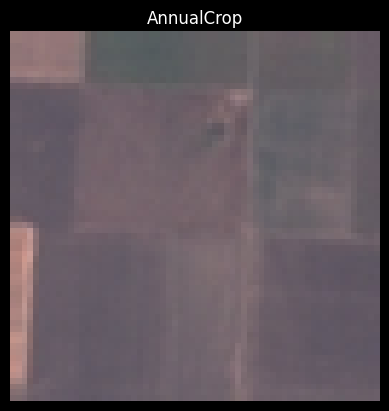

../data/EuroSAT/2750\AnnualCrop\AnnualCrop_1.jpg


In [11]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "../data/EuroSAT/2750"

# 选一个类别
class_name = os.listdir(dataset_path)[0]

class_path = os.path.join(dataset_path, class_name)

# 选一张图片
image_name = os.listdir(class_path)[0]

image_path = os.path.join(class_path, image_name)

img = Image.open(image_path)

plt.imshow(img)
plt.title(class_name)
plt.axis("off")
plt.show()
print(image_path)

In [14]:
print(os.listdir(dataset_path))

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [17]:
class_name = os.listdir(dataset_path)[0]
print(class_name)

class_path = os.path.join(dataset_path, class_name)

print(os.listdir(class_path)[:5])

image_name = os.listdir(class_path)[0]

image_path = os.path.join(class_path, image_name)

print(image_path)

img = Image.open(image_path)

AnnualCrop
['AnnualCrop_1.jpg', 'AnnualCrop_10.jpg', 'AnnualCrop_100.jpg', 'AnnualCrop_1000.jpg', 'AnnualCrop_1001.jpg']
../data/EuroSAT/2750\AnnualCrop\AnnualCrop_1.jpg


In [13]:
"""
fig, axes = plt.subplots(1,5, figsize=(15,3))

for i in range(5):

    class_name = classes[i]

    folder = os.path.join(data_path, class_name)

    img_name = os.listdir(folder)[0]

    img_path = os.path.join(folder, img_name)

    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.show()
"""

'\nfig, axes = plt.subplots(1,5, figsize=(15,3))\n\nfor i in range(5):\n\n    class_name = classes[i]\n\n    folder = os.path.join(data_path, class_name)\n\n    img_name = os.listdir(folder)[0]\n\n    img_path = os.path.join(folder, img_name)\n\n    img = Image.open(img_path)\n\n    axes[i].imshow(img)\n    axes[i].set_title(class_name)\n    axes[i].axis("off")\n\nplt.show()\n'

In [14]:
import numpy as np

img_array = np.array(img)

print(img_array.shape)

(64, 64, 3)


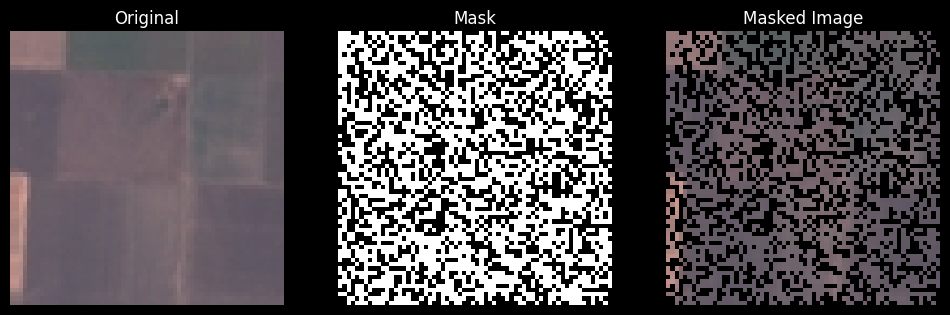

In [17]:
def generate_random_mask(image, missing_ratio=0.4):

    h, w, c = image.shape

    mask = np.random.rand(h, w) > missing_ratio

    mask = mask.astype(np.float32)

    mask = np.expand_dims(mask, axis=2)

    masked_image = image * mask

    return masked_image, mask

masked_img, mask = generate_random_mask(img_array, 0.4)

fig, axes = plt.subplots(1,3, figsize=(12,4))

axes[0].imshow(img_array)
axes[0].set_title("Original")

axes[1].imshow(mask.squeeze(), cmap="gray")
axes[1].set_title("Mask")

axes[2].imshow(masked_img.astype("uint8"))
axes[2].set_title("Masked Image")

for ax in axes:
    ax.axis("off")

plt.show()

In [18]:
"""error
from diffusers import StableDiffusionInpaintPipeline
import torch

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float32
)

pipe = pipe.to("cpu")

from PIL import Image

masked_pil = Image.fromarray(masked_img.astype("uint8"))

mask_image = (1 - mask) * 255
mask_image = mask_image.astype("uint8")

mask_pil = Image.fromarray(mask_image.squeeze())

prompt = "satellite image"

result = pipe(
    prompt=prompt,
    image=masked_pil,
    mask_image=mask_pil
).images[0]

fig, axes = plt.subplots(1,3, figsize=(12,4))

axes[0].imshow(img_array)
axes[0].set_title("Original")

axes[1].imshow(masked_img.astype("uint8"))
axes[1].set_title("Masked")

axes[2].imshow(result)
axes[2].set_title("Diffusion Reconstruction")

for ax in axes:
    ax.axis("off")

plt.show()
"""

'error\nfrom diffusers import StableDiffusionInpaintPipeline\nimport torch\n\npipe = StableDiffusionInpaintPipeline.from_pretrained(\n    "runwayml/stable-diffusion-inpainting",\n    torch_dtype=torch.float32\n)\n\npipe = pipe.to("cpu")\n\nfrom PIL import Image\n\nmasked_pil = Image.fromarray(masked_img.astype("uint8"))\n\nmask_image = (1 - mask) * 255\nmask_image = mask_image.astype("uint8")\n\nmask_pil = Image.fromarray(mask_image.squeeze())\n\nprompt = "satellite image"\n\nresult = pipe(\n    prompt=prompt,\n    image=masked_pil,\n    mask_image=mask_pil\n).images[0]\n\nfig, axes = plt.subplots(1,3, figsize=(12,4))\n\naxes[0].imshow(img_array)\naxes[0].set_title("Original")\n\naxes[1].imshow(masked_img.astype("uint8"))\naxes[1].set_title("Masked")\n\naxes[2].imshow(result)\naxes[2].set_title("Diffusion Reconstruction")\n\nfor ax in axes:\n    ax.axis("off")\n\nplt.show()\n'

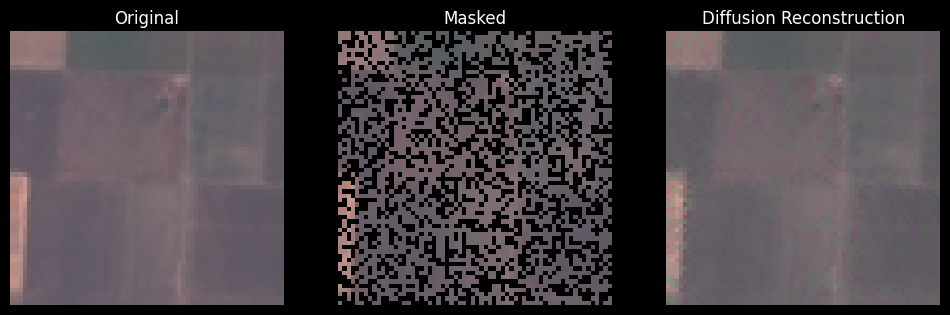

In [16]:
#Correct step 5
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Step5: Diffusion-style reconstruction
def diffusion_reconstruct(masked_image, mask, steps=50):

    # 复制图像
    reconstructed = masked_image.copy().astype(float)

    # mask=1表示原始像素存在
    known_pixels = mask

    for step in range(steps):

        # diffusion-like smoothing
        smoothed = gaussian_filter(reconstructed, sigma=1)

        # 只更新缺失区域
        reconstructed = known_pixels * reconstructed + (1 - known_pixels) * smoothed

    return reconstructed


# 运行 reconstruction
reconstructed_img = diffusion_reconstruct(masked_img, mask, steps=60)

# 显示结果
fig, axes = plt.subplots(1,3, figsize=(12,4))

axes[0].imshow(img_array)
axes[0].set_title("Original")

axes[1].imshow(masked_img.astype("uint8"))
axes[1].set_title("Masked")

axes[2].imshow(reconstructed_img.astype("uint8"))
axes[2].set_title("Diffusion Reconstruction")

for ax in axes:
    ax.axis("off")

plt.show()

In [25]:
"""Cloud Mask Simulation: Not satisfactory enough

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


def generate_cloud_mask(image, cloud_size=20, cloud_intensity=0.8):

    h, w, c = image.shape

    # 随机生成一个噪声图
    noise = np.random.rand(h, w)

    # 使用高斯滤波让它变得像云
    cloud = gaussian_filter(noise, sigma=cloud_size)

    # 归一化
    cloud = (cloud - cloud.min()) / (cloud.max() - cloud.min())

    # 阈值化得到云区域
    cloud_mask = cloud > cloud_intensity

    # 扩展到RGB
    cloud_mask = np.repeat(cloud_mask[:, :, np.newaxis], 3, axis=2)

    # 生成被云遮挡的图像
    cloudy_image = image.copy()
    cloudy_image[cloud_mask] = 255  # 白色云层

    return cloudy_image, cloud_mask


# 生成云遮挡
cloudy_img, cloud_mask = generate_cloud_mask(img_array)

# 显示
fig, axes = plt.subplots(1,3, figsize=(12,4))

axes[0].imshow(img_array)
axes[0].set_title("Original")

axes[1].imshow(cloud_mask[:,:,0], cmap="gray")
axes[1].set_title("Cloud Mask")

axes[2].imshow(cloudy_img)
axes[2].set_title("Cloudy Image")

for ax in axes:
    ax.axis("off")

plt.show()
"""

'Cloud Mask Simulation: Not satisfactory enough\n\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom scipy.ndimage import gaussian_filter\n\n\ndef generate_cloud_mask(image, cloud_size=20, cloud_intensity=0.8):\n\n    h, w, c = image.shape\n\n    # 随机生成一个噪声图\n    noise = np.random.rand(h, w)\n\n    # 使用高斯滤波让它变得像云\n    cloud = gaussian_filter(noise, sigma=cloud_size)\n\n    # 归一化\n    cloud = (cloud - cloud.min()) / (cloud.max() - cloud.min())\n\n    # 阈值化得到云区域\n    cloud_mask = cloud > cloud_intensity\n\n    # 扩展到RGB\n    cloud_mask = np.repeat(cloud_mask[:, :, np.newaxis], 3, axis=2)\n\n    # 生成被云遮挡的图像\n    cloudy_image = image.copy()\n    cloudy_image[cloud_mask] = 255  # 白色云层\n\n    return cloudy_image, cloud_mask\n\n\n# 生成云遮挡\ncloudy_img, cloud_mask = generate_cloud_mask(img_array)\n\n# 显示\nfig, axes = plt.subplots(1,3, figsize=(12,4))\n\naxes[0].imshow(img_array)\naxes[0].set_title("Original")\n\naxes[1].imshow(cloud_mask[:,:,0], cmap="gray")\naxes[1].set_title("Cloud Mask

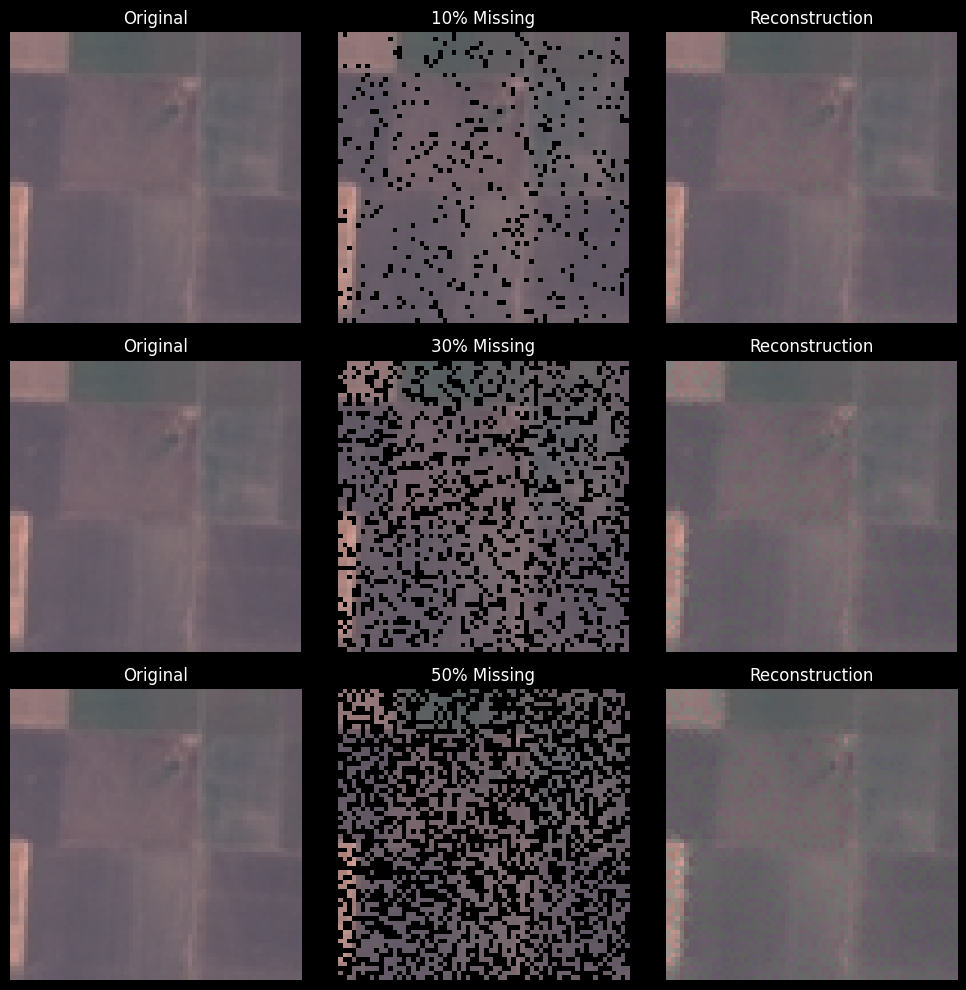

In [26]:
import numpy as np
import matplotlib.pyplot as plt


def run_missing_experiment(img_array):

    ratios = [0.1, 0.3, 0.5]

    fig, axes = plt.subplots(len(ratios), 3, figsize=(10, 10))

    for i, ratio in enumerate(ratios):

        # 生成mask
        mask = np.random.rand(*img_array.shape[:2]) > ratio
        mask = np.repeat(mask[:, :, np.newaxis], 3, axis=2)

        # masked image
        masked_img = img_array * mask

        # diffusion reconstruction
        recon = diffusion_reconstruct(masked_img, mask, steps=60)

        # plot
        axes[i,0].imshow(img_array)
        axes[i,0].set_title("Original")

        axes[i,1].imshow(masked_img.astype("uint8"))
        axes[i,1].set_title(f"{int(ratio*100)}% Missing")

        axes[i,2].imshow(recon.astype("uint8"))
        axes[i,2].set_title("Reconstruction")

        for j in range(3):
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.show()


# 运行实验
run_missing_experiment(img_array)

In [27]:
import numpy as np


def compute_psnr(original, reconstructed):

    # 转为float
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)

    mse = np.mean((original - reconstructed) ** 2)

    if mse == 0:
        return 100

    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))

    return psnr

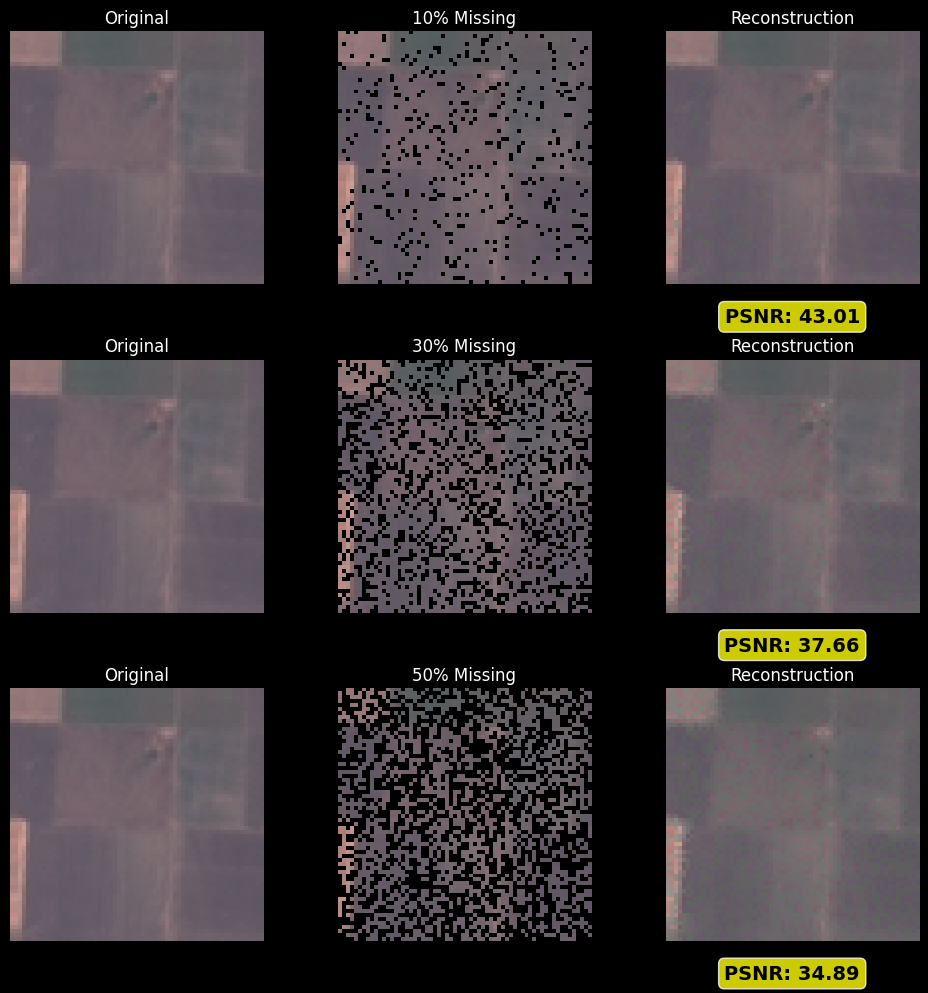

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def run_missing_experiment(img_array):

    ratios = [0.1, 0.3, 0.5]

    fig, axes = plt.subplots(len(ratios), 3, figsize=(10, 10))

    for i, ratio in enumerate(ratios):

        mask = np.random.rand(*img_array.shape[:2]) > ratio
        mask = np.repeat(mask[:, :, np.newaxis], 3, axis=2)

        masked_img = img_array * mask

        recon = diffusion_reconstruct(masked_img, mask, steps=60)

        psnr_value = compute_psnr(img_array, recon)

        axes[i,0].imshow(img_array)
        axes[i,0].set_title("Original", fontsize=12)

        axes[i,1].imshow(masked_img.astype("uint8"))
        axes[i,1].set_title(f"{int(ratio*100)}% Missing", fontsize=12)

        axes[i,2].imshow(recon.astype("uint8"))
        axes[i,2].set_title("Reconstruction", fontsize=12)

        # ⭐ 在图像下方高亮PSNR
        axes[i,2].text(
            0.5, -0.15,
            f"PSNR: {psnr_value:.2f}",
            fontsize=14,
            fontweight="bold",
            color="black",
            ha="center",
            transform=axes[i,2].transAxes,
            bbox=dict(facecolor="yellow", alpha=0.8, boxstyle="round")
        )

        for j in range(3):
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.show()


run_missing_experiment(img_array)